In [ ]:
# Ensure repository-root working directory after notebook relocation
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
repo_root = cwd
if not (repo_root / 'pyproject.toml').exists():
    for parent in [cwd, *cwd.parents]:
        if (parent / 'pyproject.toml').exists():
            repo_root = parent
            break
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print(f'Working directory: {repo_root}')


In [1]:
import pickle

pathway = "./inter_comp_data/"
synplanner_clusters = pickle.load(open(pathway + "synplanner_clusters.pkl", "rb"))
askcos_clusters = pickle.load(open(pathway + "askcos_clusters.pkl", "rb"))
aizynth_clusters = pickle.load(open(pathway + "aizynth_clusters.pkl", "rb"))

In [2]:
syn = {str(cluster['sb_cgr']) for cluster in synplanner_clusters.values()}
ask = {str(cluster['sb_cgr']) for cluster in askcos_clusters.values()}
aiz = {str(cluster['sb_cgr']) for cluster in aizynth_clusters.values()}

### Wenn diagram of overlap SB-CGR of routes in all tools

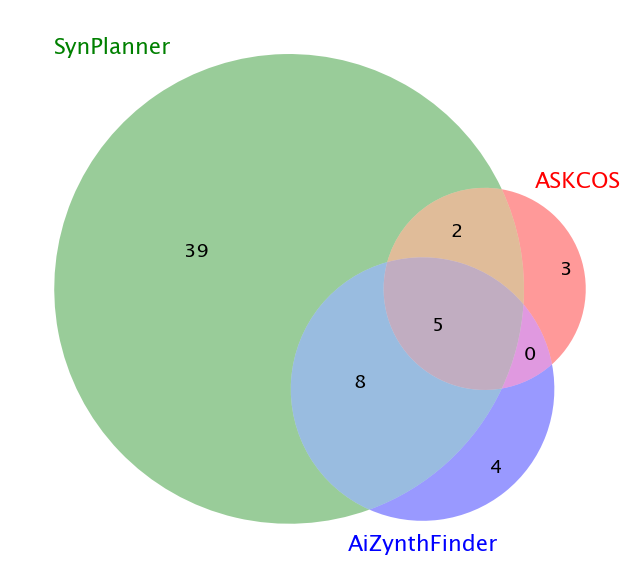

In [3]:
from cgr_clustering.visualization import plot_venn_diagram

plot_venn_diagram(syn, ask, aiz)

In [4]:
from cgr_clustering.utils import collect_overlaps, make_keys_for_sb, merge_keys_for_sbs

df = collect_overlaps(syn, ask, aiz)
df

,Region,Count,Examples
0,Only SynPlanner,39,[c1cnccc1CN[.>-]c2ncccc2[.>-]C([.>-]N[.>-]c3cc...
1,Only ASKCOS,3,[C1CCCC1(c2ccc(cc2)N[.>-]C([.>-]c3cccnc3[.>-]N...
2,Only AiZynthFinder,4,[c1cc(ccc1C2(CCCC2)C[.>#]N)[.>-]N[.>-]C(=O)c3c...
3,SynPlanner ∩ ASKCOS,2,[C1CCCC1(c2ccc(cc2)N[.>-]C([.>=]O)[.>-]c3c(ncc...
4,SynPlanner ∩ AiZynthFinder,8,[C1CCCC1(c2ccc(cc2)N[.>-]C(c3c(nccc3)N[.>-]Cc4...
5,ASKCOS ∩ AiZynthFinder,0,[]
6,All Three,5,[C1CCCC1(C#N)c2ccc(cc2)NC(=O)c3cccnc3[.>-]NCc4...


In [8]:
df.Count.sum()

np.int64(61)

In [19]:
keys_for_sb = make_keys_for_sb(synplanner_clusters, askcos_clusters, aizynth_clusters)

row_id = 3 # In the given example SynPlanner ∩ ASKCOS results

examples = df.loc[row_id, "Examples"]
print('Number of SB-CGRs:', len(examples))

merged = merge_keys_for_sbs(examples, keys_for_sb)
merged

Number of SB-CGRs: 2


{'synplanner_keys': ['4.8', '2.3'],
 'askcos_keys': ['4.1', '2.2'],
 'aizynth_keys': []}

In [27]:
from synplan.chem.reaction_routes.visualisation import cgr_display
from IPython.display import display, SVG

for tool_key, val_sb_cgrs in merged.items():
    if len(val_sb_cgrs) != 0:
        print(tool_key)
        for i in val_sb_cgrs:
            print(i)
            if tool_key == 'aizynth_keys':
                w = aizynth_clusters[i]['sb_cgr']
            if tool_key == 'synplanner_keys':
                w = synplanner_clusters[i]['sb_cgr']
            if tool_key == 'askcos_keys':
                w = askcos_clusters[i]['sb_cgr']
            w.clean2d()
            display(SVG(cgr_display(w)))


synplanner_keys
4.8


2.3


askcos_keys
4.1


2.2


### Strategic bond number histogram

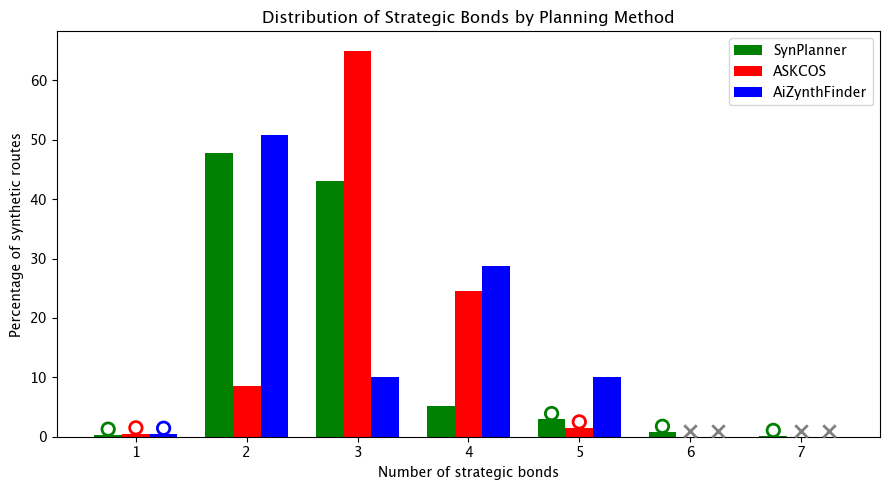

In [7]:
from cgr_clustering.utils import compute_group_percentages
from cgr_clustering.visualization import plot_sb_histogram

synplanner_perc = compute_group_percentages(synplanner_clusters)
askcos_perc =  compute_group_percentages(askcos_clusters)
aizynth_perc = compute_group_percentages(aizynth_clusters)

plot_sb_histogram(synplanner_perc, askcos_perc, aizynth_perc)